# MFSTNet — results

Everything below is read from **committed CSVs** in `experiments/results/`. Nothing
here computes a metric from scratch: the numbers were written by the script that
produced them (NFR-09), and `mfstnet.metrics` is the single implementation of
every metric in the project.

That matters more than it sounds. If this notebook re-derived F1, there would be
two implementations that could disagree, and the one in the report would be
whichever was run last.

**Re-run headlessly** the way CI would:

```bash
python scripts/run_notebook.py notebooks/03_results.ipynb
```

In [1]:
import sys
from pathlib import Path

# The inline backend ipykernel provides renders correctly under nbclient AND in
# VS Code. Forcing "Agg" instead looks headless-safe and silently produces no
# figure at all — plt.show() just warns.
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from mfstnet.metrics import DEFAULT_LABELS, format_confusion_matrix

RESULTS = ROOT / "experiments" / "results"
available = sorted(RESULTS.glob("*.csv"))
print(f"{len(available)} result file(s) in {RESULTS.relative_to(ROOT)}:")
for path in available:
    print("   ", path.name)

1 result file(s) in experiments\results:
    overfit_check.csv


## What is in scope

The table below lists every committed result CSV and what it may and may not be
used to claim. This cell is deliberately first: the most expensive mistake
available here is presenting a diagnostic as a result.

In [2]:
PROVENANCE = {
    "overfit_check.csv": (
        "DIAGNOSTIC — NOT A RESULT. Random features fitted to random labels to "
        "prove the graph can learn (S26). Its 1.00 accuracy says nothing about "
        "traffic; there is no signal to generalise from, by construction."
    ),
    "ablation.csv": "§14.4 ablation, 8 configs x 5 seeds, real corpus.",
    "rl_benchmark.csv": "§14.3 RL benchmark, 30 seeds per method.",
}

for path in available:
    note = PROVENANCE.get(path.name, "UNREGISTERED — add it to PROVENANCE above.")
    print(f"{path.name}\n    {note}\n")

overfit_check.csv
    DIAGNOSTIC — NOT A RESULT. Random features fitted to random labels to prove the graph can learn (S26). Its 1.00 accuracy says nothing about traffic; there is no signal to generalise from, by construction.



## Confusion matrix

Rows are truth, columns are prediction. The direction of an error is the whole
point and an aggregate F1 hides it: for a signal controller, calling a HIGH lane
LOW is a very different failure from calling a LOW lane HIGH — the first starves
a queue, the second wastes green time.

`ordinal_mae` and `off_by_two_rate` are reported beside the usual metrics because
LOW < MEDIUM < HIGH is **ordered**. Plain macro-F1 treats a LOW-called-HIGH error
as no worse than LOW-called-MEDIUM, which is wrong for this task.

In [3]:
def confusion_from_row(row, labels=DEFAULT_LABELS):
    """Rebuild the matrix from the flat `cm_<truth>_as_<pred>` columns that
    `mfstnet.metrics.Report.as_row()` writes."""
    return [
        [int(row[f"cm_{t.lower()}_as_{p.lower()}"]) for p in labels]
        for t in labels
    ]


def show_row(row, title):
    print(title)
    print(format_confusion_matrix(confusion_from_row(row)))
    print()
    for label in DEFAULT_LABELS:
        key = label.lower()
        print(
            f"  {label:<7} precision {row[f'precision_{key}']:.3f}"
            f"   recall {row[f'recall_{key}']:.3f}"
            f"   F1 {row[f'f1_{key}']:.3f}"
            f"   support {int(row[f'support_{key}'])}"
        )
    print(
        f"\n  accuracy {row['accuracy']:.4f}   macro-F1 {row['macro_f1']:.4f}"
        f"   weighted-F1 {row['weighted_f1']:.4f}"
    )
    print(
        f"  ordinal MAE {row['ordinal_mae']:.4f}"
        f"   off-by-two {row['off_by_two_rate']:.4f}"
        f"   QWK {row['qwk']:.4f}"
    )


overfit_path = RESULTS / "overfit_check.csv"
overfit = pd.read_csv(overfit_path) if overfit_path.exists() else None

if overfit is None:
    print("no overfit_check.csv yet — run: python scripts/overfit_check.py --all")
elif "cm_low_as_low" not in overfit.columns:
    # An older CSV written before the full metrics row was merged in. Say so
    # rather than raising: a result file is an artifact of the run that made it,
    # and rewriting one by hand to fit a newer schema is how numbers get lost.
    print(
        "This CSV predates the full metrics row (no cm_* columns). "
        "Re-run `python scripts/overfit_check.py --all` to regenerate it."
    )
else:
    show_row(overfit.iloc[-1], f"config {overfit.iloc[-1]['config']}  (DIAGNOSTIC)")

config H  (DIAGNOSTIC)
                    predicted        
                  LOW  MEDIUM    HIGH
     LOW           16       0       0
true MEDIUM         0       7       0
     HIGH           0       0      17

  LOW     precision 1.000   recall 1.000   F1 1.000   support 16
  MEDIUM  precision 1.000   recall 1.000   F1 1.000   support 7
  HIGH    precision 1.000   recall 1.000   F1 1.000   support 17

  accuracy 1.0000   macro-F1 1.0000   weighted-F1 1.0000
  ordinal MAE 0.0000   off-by-two 0.0000   QWK 1.0000


## Ablation configs

Once `ablation.csv` exists this reports mean ± 95% CI over the five seeds
amendment A23 requires. A two-point macro-F1 gap between configs is meaningless
without seed variance — config F demonstrated that during S26, passing at seeds
1–3 and failing at 42 for reasons that had nothing to do with the architecture.

**Watch config H.** It is the linear probe: frozen features, per-lane pool, mean
over time, linear head. If H approaches G, the architecture is not justified, and
that is the finding to report rather than bury (BR-19).

no ablation.csv yet (needs S28). Showing the overfit diagnostic's
shape instead, so the plotting path is exercised and not left untested.


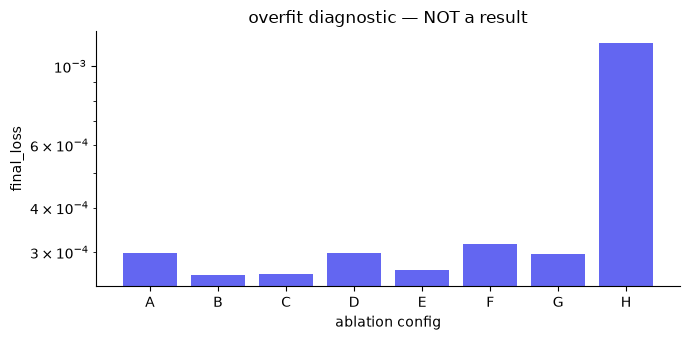

In [4]:
ablation_path = RESULTS / "ablation.csv"

if ablation_path.exists():
    df = pd.read_csv(ablation_path)
    summary = df.groupby("config")["macro_f1"].agg(["mean", "std", "count"])
    display(summary)
    frame, metric = df, "macro_f1"
else:
    print("no ablation.csv yet (needs S28). Showing the overfit diagnostic's")
    print("shape instead, so the plotting path is exercised and not left untested.")
    frame, metric = overfit, "final_loss"

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(frame["config"], frame[metric], color="#6366F1")
ax.set_xlabel("ablation config")
ax.set_ylabel(metric)
ax.set_title(
    "§14.4 ablation" if ablation_path.exists()
    else "overfit diagnostic — NOT a result"
)
if metric == "final_loss":
    ax.set_yscale("log")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## The gate

`g = sigmoid(Linear([Z_A; Z_B]))` decides how much the fused representation leans
on CNN-queries-ViT versus the reverse. It is a **research artifact**, not an
internal detail (BR-07, FR-M04), and §14.2's hypothesis is that it shifts with
scene density.

A gate that sits at 0.5 everywhere is itself a result: it would mean the two
directions are interchangeable and the gate is not doing the job claimed for it.
At initialisation it should sit near 0.5, so only a **trained** model's gate is
evidence of anything.

In [5]:
gate_rows = overfit.dropna(subset=["gate_mean"]) if overfit is not None else None

if gate_rows is not None and len(gate_rows):
    for _, row in gate_rows.iterrows():
        print(f"  config {row['config']}   gate mean {row['gate_mean']:.4f}")
    print(
        "\n  Near 0.5, as expected — this model was fitted to random noise, so"
        "\n  neither direction carries more signal than the other. Read nothing"
        "\n  into it. The density analysis needs a model trained on real footage."
    )
else:
    print("no gate values yet — only config G produces one.")

  config G   gate mean 0.4999

  Near 0.5, as expected — this model was fitted to random noise, so
  neither direction carries more signal than the other. Read nothing
  into it. The density analysis needs a model trained on real footage.
